# 3b — Rigid-Body Motions & Twists: from scratch

Code companion to `notes/03b_rigid_motions_twists.md`. We build, from scratch
with numpy, the core `SE(3)` machinery:

- transforms `T = [[R, p], [0, 1]]` — building, acting on points, composing
- the inverse `T⁻¹` via its block form (no general 4×4 inverse)
- twists `[V]` (se(3)) and the **adjoint** `[Ad_T]` that moves a twist between
  frames
- screw axes, and `exp([S]θ)` / `log(T)` — the SE(3) bridge, visualized as a
  helix

We implement everything by hand first (that's where the learning is), then
cross-check against the official `modern_robotics` package at the end.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))  # project root, for `import mr`

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

from mr.so3 import vec_to_so3, so3_to_vec, matrix_exp3, matrix_log3
from mr.plotting import draw_frame, setup_3d_axes

np.set_printoptions(precision=3, suppress=True)

## 1. Building a transform `T` from `(R, p)`

`T_sb` stacks the orientation `R_sb` (top-left 3×3) and the origin position
`p_sb` (top-right 3×1), with a `[0 0 0 1]` bottom row. Recreate the note's
figure: `{b}` is `{s}` rotated 90° about z and shifted to `(2, 1.5, 0.8)`.

In [2]:
def rp_to_trans(R, p):
    """(R, p) -> 4x4 homogeneous transform T = [[R, p], [0, 1]]."""
    R = np.asarray(R, dtype=float)
    p = np.asarray(p, dtype=float).reshape(3)
    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3] = p
    return T


def trans_to_rp(T):
    """T -> (R, p). Inverse of rp_to_trans."""
    T = np.asarray(T, dtype=float)
    return T[:3, :3], T[:3, 3]


R_sb = matrix_exp3(np.array([0, 0, 1.0]), np.pi / 2)   # 90 deg about z
p_sb = np.array([2.0, 1.5, 0.8])
T_sb = rp_to_trans(R_sb, p_sb)
print("T_sb =\n", T_sb)
print("\nlast column top-3 = position of {b}'s origin in {s}:", T_sb[:3, 3])

T_sb =
 [[ 0.  -1.   0.   2. ]
 [ 1.   0.   0.   1.5]
 [ 0.   0.   1.   0.8]
 [ 0.   0.   0.   1. ]]

last column top-3 = position of {b}'s origin in {s}: [2.  1.5 0.8]


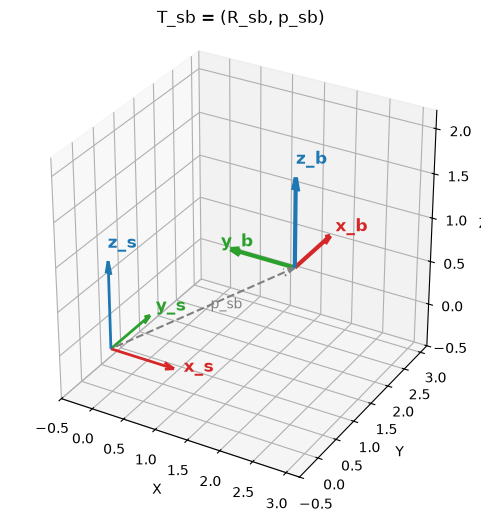

In [3]:
# Visualize: {s} at the origin, {b} rotated AND translated to p_sb
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
draw_frame(ax, np.eye(3), labels=("x_s", "y_s", "z_s"), lw=2)
draw_frame(ax, R_sb, origin=p_sb, labels=("x_b", "y_b", "z_b"), lw=3)
ax.quiver(0, 0, 0, *p_sb, color="gray", ls="--", lw=1.5, arrow_length_ratio=0.06)
ax.text(*(p_sb * 0.5), "  p_sb", color="gray")
setup_3d_axes(ax, lim=3, title="T_sb = (R_sb, p_sb)")
ax.set_xlim(-0.5, 3.2); ax.set_ylim(-0.5, 3.2); ax.set_zlim(-0.5, 2.2)
plt.show()

## 2. `T` acts on points — via homogeneous coordinates

A 3×3 matrix can't translate (it always fixes the origin). The trick: append a
`1` to a point, making it 4D, so a single 4×4 multiply does **rotate + shift**:

```
T · (x, 1) = (Rx + p, 1)
```

Append a `0` instead of `1` for a *direction* — directions only rotate, never
translate.

In [4]:
def apply_to_point(T, x):
    """Transform a 3D point: rotate then translate (append 1)."""
    x = np.asarray(x, dtype=float).reshape(3)
    return (T @ np.append(x, 1.0))[:3]


def apply_to_direction(T, d):
    """Transform a 3D direction: rotate only (append 0)."""
    d = np.asarray(d, dtype=float).reshape(3)
    return (T @ np.append(d, 0.0))[:3]


# A point at {b}'s origin in body coords is (0,0,0); in space it should be p_sb.
print("point (0,0,0)_b in {s}:", apply_to_point(T_sb, [0, 0, 0]))   # -> p_sb

# Body x-axis tip (1,0,0)_b lands at p_sb + (first column of R_sb)
print("point (1,0,0)_b in {s}:", apply_to_point(T_sb, [1, 0, 0]))
print("R_sb first column      :", R_sb[:, 0], " (so the difference is p_sb)")

# A pure direction ignores the translation:
print("\ndirection (1,0,0)_b in {s}:", apply_to_direction(T_sb, [1, 0, 0]),
      " == R_sb[:,0], no p_sb added")

point (0,0,0)_b in {s}: [2.  1.5 0.8]
point (1,0,0)_b in {s}: [2.  2.5 0.8]
R_sb first column      : [0. 1. 0.]  (so the difference is p_sb)

direction (1,0,0)_b in {s}: [0. 1. 0.]  == R_sb[:,0], no p_sb added


## 3. Composition `T_sb · T_bc = T_sc`

Chaining frames, exactly like rotations. Block multiply gives new rotation
`R_sb R_bc` and new position `R_sb p_bc + p_sb` — note the inner offset `p_bc`
is **rotated into `{s}` first**, then `p_sb` is added.

In [5]:
# {c}: rotated -90 deg about x relative to {b}, offset (0, 0, 1) along z_b
R_bc = matrix_exp3(np.array([1.0, 0, 0]), -np.pi / 2)
T_bc = rp_to_trans(R_bc, [0, 0, 1])

T_sc = T_sb @ T_bc
R_sc, p_sc = trans_to_rp(T_sc)
print("p_sc =", p_sc)
print("check R_sb @ p_bc + p_sb =", R_sb @ np.array([0, 0, 1]) + p_sb, " (matches)")

p_sc = [2.  1.5 1.8]
check R_sb @ p_bc + p_sb = [2.  1.5 1.8]  (matches)


## 4. The inverse `T⁻¹` — block form, not a transpose

`T` isn't orthogonal, so `T⁻¹ ≠ Tᵀ`. The inverse is
`[[Rᵀ, -Rᵀp], [0, 1]]`: undo the shift (`-p`) then undo the rotation (`Rᵀ`),
and applying `Rᵀ` also rotates the offset → `-Rᵀp`.

In [6]:
def trans_inv(T):
    """Inverse of T in SE(3): [[R^T, -R^T p], [0, 1]]."""
    R, p = trans_to_rp(T)
    Rt = R.T
    return rp_to_trans(Rt, -Rt @ p)


T_bs = trans_inv(T_sb)
print("T_sb^-1 =\n", T_bs)
print("\nT_sb @ T_sb^-1 == I ?", np.allclose(T_sb @ T_bs, np.eye(4)))
print("matches np.linalg.inv ?", np.allclose(T_bs, np.linalg.inv(T_sb)))

T_sb^-1 =
 [[ 0.   1.   0.  -1.5]
 [-1.   0.   0.   2. ]
 [ 0.   0.   1.  -0.8]
 [ 0.   0.   0.   1. ]]

T_sb @ T_sb^-1 == I ? True
matches np.linalg.inv ? True


## 5. Twists — the 6-vector velocity of a rigid body

A twist `V = (ω, v)` packs angular + linear velocity. Its matrix form lives in
se(3): `[V] = [[ [ω], v ], [0, 0]]`. We'll also confirm the two flavors from a
moving `T(t)`:

- `[V_b] = T⁻¹ Ṫ`  (body twist — `v_b` is the body's **own origin** velocity)
- `[V_s] = Ṭ T⁻¹`  (spatial twist — `v_s` tracks the body-point at the **world
  origin**)

In [7]:
def vec_to_se3(V):
    """6-vector V=(omega,v) -> 4x4 [V] = [[ [omega], v ], [0, 0]]."""
    V = np.asarray(V, dtype=float).reshape(6)
    se3 = np.zeros((4, 4))
    se3[:3, :3] = vec_to_so3(V[:3])
    se3[:3, 3] = V[3:]
    return se3


def se3_to_vec(se3mat):
    """4x4 se(3) -> 6-vector twist."""
    se3mat = np.asarray(se3mat, dtype=float)
    return np.concatenate([so3_to_vec(se3mat[:3, :3]), se3mat[:3, 3]])


V = np.array([0, 0, 2, -2, -4, 0])  # the spatial twist from book Example 3.23
print("[V] =\n", vec_to_se3(V))
print("\nround trip se3_to_vec:", se3_to_vec(vec_to_se3(V)))

[V] =
 [[ 0. -2.  0. -2.]
 [ 2.  0. -0. -4.]
 [-0.  0.  0.  0.]
 [ 0.  0.  0.  0.]]

round trip se3_to_vec: [ 0.  0.  2. -2. -4.  0.]


### Numerically check `[V_b] = T⁻¹ Ṫ` and `[V_s] = Ṭ T⁻¹`

Spin `{b}` about the space z-axis at 1 rad/s while its origin drifts. Build
`T(t)`, finite-difference `Ṫ`, and read off the twists. We'll confirm `V_s` is
**not** just `(ω, ṗ)`.

In [8]:
omega_w = np.array([0, 0, 1.0])             # world-frame angular velocity
def T_of_t(t):
    R = matrix_exp3(omega_w, t)              # spinning about world z
    p = np.array([np.cos(t), np.sin(t), 0]) # origin riding a unit circle
    return rp_to_trans(R, p)

t0, dt = 0.7, 1e-6
T0 = T_of_t(t0)
Tdot = (T_of_t(t0 + dt) - T_of_t(t0 - dt)) / (2 * dt)

Vb = se3_to_vec(trans_inv(T0) @ Tdot)
Vs = se3_to_vec(Tdot @ trans_inv(T0))
print("V_b = (omega_b, v_b) =", Vb)
print("V_s = (omega_s, v_s) =", Vs)
print("\np_dot (origin velocity in {s}) =", Tdot[:3, 3])
print("note v_s != p_dot -- v_s tracks the body-point at the WORLD origin")

V_b = (omega_b, v_b) = [0. 0. 1. 0. 1. 0.]
V_s = (omega_s, v_s) = [0. 0. 1. 0. 0. 0.]

p_dot (origin velocity in {s}) = [-0.644  0.765  0.   ]
note v_s != p_dot -- v_s tracks the body-point at the WORLD origin


## 6. The adjoint `[Ad_T]` — move a twist between frames

`V_s = [Ad_(T_sb)] V_b`. Shape: `[[R, 0], [ [p]R, R ]]`. The `[p]R` block is
the `ω × p` lever-arm correction — `ω` changes by pure basis change, but `v`
also picks up the lever arm because `v_s` and `v_b` track *different points*.

In [9]:
def adjoint(T):
    """T -> 6x6 [Ad_T] = [[R, 0], [ [p]R, R ]]."""
    R, p = trans_to_rp(T)
    Ad = np.zeros((6, 6))
    Ad[:3, :3] = R
    Ad[3:, :3] = vec_to_so3(p) @ R
    Ad[3:, 3:] = R
    return Ad


# The Adjoint must convert the V_b we measured above back into V_s:
print("[Ad_T0] V_b =", adjoint(T0) @ Vb)
print("V_s        =", Vs)
print("match ?", np.allclose(adjoint(T0) @ Vb, Vs))

[Ad_T0] V_b = [0. 0. 1. 0. 0. 0.]
V_s        = [0. 0. 1. 0. 0. 0.]
match ? True


In [10]:
# Illustrate the 'different points' point from the FAQ:
# disk spinning about its own center (v_b = 0), world origin sitting on the rim.
T_rim = rp_to_trans(np.eye(3), [1, 0, 0])     # p = (1,0,0), R = I (aligned now)
Vb_disk = np.array([0, 0, 1, 0, 0, 0])        # spin only, center not translating
Vs_disk = adjoint(T_rim) @ Vb_disk
print("v_b =", Vb_disk[3:], "(center stationary)")
print("v_s =", Vs_disk[3:], "(rim point moving, even though R = I!)  = p x omega")

v_b = [0 0 0] (center stationary)
v_s = [ 0. -1.  0.] (rim point moving, even though R = I!)  = p x omega


## 7. Screw axes & `exp([S]θ)` — rotating about + sliding along one axis

Any rigid motion is a screw: rotate by `θ` about a line *and* translate `hθ`
along it (Chasles–Mozzi). A screw axis `S = (ω, v)` is a normalized twist; from
geometry `{point q, unit axis ŝ, pitch h}`: `ω = ŝ`, `v = -ŝ×q + hŝ`.

`exp([S]θ)` builds `T`. The position block is `G(θ)v`, **not** `vθ` — the body
rotates as it translates, so the origin follows a helix.

In [11]:
def screw_to_axis(q, s_hat, h):
    """Geometric screw {q, s_hat, h} -> normalized S = (omega, v)."""
    q = np.asarray(q, dtype=float).reshape(3)
    s_hat = np.asarray(s_hat, dtype=float).reshape(3)
    return np.concatenate([s_hat, -np.cross(s_hat, q) + h * s_hat])


def _G(omega_hat, theta):
    om = vec_to_so3(omega_hat)
    return (np.eye(3) * theta
            + (1 - np.cos(theta)) * om
            + (theta - np.sin(theta)) * (om @ om))


def matrix_exp6(S, theta):
    """Screw axis S=(omega,v) + distance theta -> T in SE(3)."""
    S = np.asarray(S, dtype=float).reshape(6)
    omega, v = S[:3], S[3:]
    if np.linalg.norm(omega) < 1e-12:          # pure translation
        return rp_to_trans(np.eye(3), v * theta)
    return rp_to_trans(matrix_exp3(omega, theta), _G(omega, theta) @ v)


# The door from note section 9: vertical hinge through (0,1,0), pitch 0.
S_door = screw_to_axis(q=[0, 1, 0], s_hat=[0, 0, 1], h=0)
print("screw axis S =", S_door, " (h=0 -> revolute / pure rotation)")
T_quarter = matrix_exp6(S_door, np.pi / 2)
print("\nT after a quarter turn =\n", T_quarter)
print("\nmatches the note's worked example (p = (1,1,0)) ?",
      np.allclose(T_quarter[:3, 3], [1, 1, 0]))

screw axis S = [0. 0. 1. 1. 0. 0.]  (h=0 -> revolute / pure rotation)

T after a quarter turn =
 [[ 0. -1.  0.  1.]
 [ 1.  0.  0.  1.]
 [ 0.  0.  1.  0.]
 [ 0.  0.  0.  1.]]

matches the note's worked example (p = (1,1,0)) ? True


### Visualize the screw motion as a helix

A screw with nonzero pitch traces a helix: the body-frame origin spirals around
the axis `ŝ` while climbing along it. Sample `exp([S]θ)` over a range of `θ`.

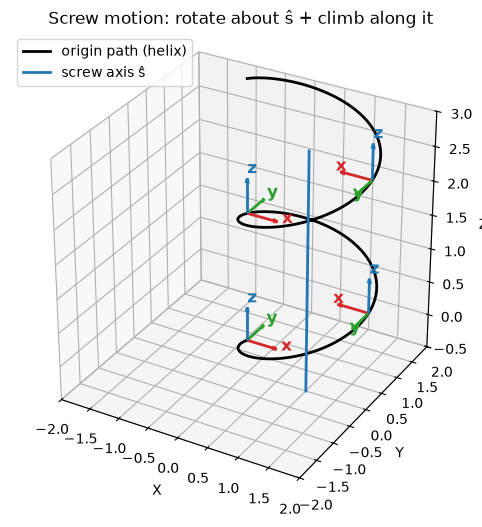

In [12]:
S_helix = screw_to_axis(q=[1, 0, 0], s_hat=[0, 0, 1], h=0.3)  # pitch 0.3
thetas = np.linspace(0, 4 * np.pi, 300)
pts = np.array([matrix_exp6(S_helix, t)[:3, 3] for t in thetas])

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot(*pts.T, color="black", lw=2, label="origin path (helix)")
ax.plot([1, 1], [0, 0], [-0.5, 3], color="tab:blue", lw=2, label="screw axis ŝ")
for t in [0, np.pi, 2 * np.pi, 3 * np.pi]:
    T = matrix_exp6(S_helix, t)
    draw_frame(ax, T[:3, :3], origin=T[:3, 3], length=0.5, lw=2)
setup_3d_axes(ax, lim=2, title="Screw motion: rotate about ŝ + climb along it")
ax.set_zlim(-0.5, 3); ax.legend()
plt.show()

## 8. `log(T)` — recover the screw axis from a transform

The inverse of `exp`: given `T`, find the single screw `(S, θ)` that achieves
it. Uses `G⁻¹(θ)` to undo the position coupling. Round-trips with `exp`.

In [13]:
def matrix_log6(T):
    """T -> (S, theta), S=(omega,v) a normalized screw axis. Inverse of matrix_exp6."""
    R, p = trans_to_rp(T)
    if np.allclose(R, np.eye(3)):              # pure translation
        dist = np.linalg.norm(p)
        if dist < 1e-12:
            return np.zeros(6), 0.0
        return np.concatenate([np.zeros(3), p / dist]), dist
    omega_hat, theta = matrix_log3(R)
    om = vec_to_so3(omega_hat)
    Ginv = (np.eye(3) / theta - om / 2
            + (1 / theta - 1 / (2 * np.tan(theta / 2))) * (om @ om))
    return np.concatenate([omega_hat, Ginv @ p]), theta


S_rec, th_rec = matrix_log6(T_quarter)
print("log(T_quarter): S =", S_rec, " theta =", th_rec)
print("original door screw * (pi/2):", S_door * (np.pi / 2))
print("exp(log(T)) == T ?", np.allclose(matrix_exp6(S_rec, th_rec), T_quarter))

log(T_quarter): S = [0. 0. 1. 1. 0. 0.]  theta = 1.5707963267948966
original door screw * (pi/2): [0.    0.    1.571 1.571 0.    0.   ]
exp(log(T)) == T ? True


## 9. Cross-check everything against the `modern_robotics` package

Sanity check our from-scratch SE(3) ops against the official implementation.

In [14]:
import modern_robotics as mr

T = T_sb
Vrand = np.array([0.3, -0.2, 1.1, 0.5, -0.7, 0.2])

checks = {
    "TransInv":     (trans_inv(T),                 mr.TransInv(T)),
    "VecTose3":     (vec_to_se3(Vrand),            mr.VecTose3(Vrand)),
    "se3ToVec":     (se3_to_vec(vec_to_se3(Vrand)), mr.se3ToVec(mr.VecTose3(Vrand))),
    "Adjoint":      (adjoint(T),                    mr.Adjoint(T)),
    "MatrixExp6":   (matrix_exp6(S_door, np.pi / 2),
                     mr.MatrixExp6(mr.VecTose3(S_door * np.pi / 2))),
    "MatrixLog6":   (vec_to_se3(S_rec) * th_rec,    mr.MatrixLog6(T_quarter)),
}
for name, (ours, theirs) in checks.items():
    print(f"{name:12s} match: {np.allclose(ours, theirs)}")

TransInv     match: True
VecTose3     match: True
se3ToVec     match: True
Adjoint      match: True
MatrixExp6   match: True
MatrixLog6   match: True


## Takeaways

- `T = (R, p)` is one object for **pose**; homogeneous coords let a single 4×4
  multiply do rotate-then-translate. Append `1` for points, `0` for directions.
- `T⁻¹` has the block form `[[Rᵀ, -Rᵀp], [0, 1]]` — only `R` transposes.
- A **twist** `V = (ω, v)` is the 6-vector velocity. `V_b` and `V_s` are the
  same motion in two frames; `[Ad_T]` converts them, and its `[p]R` block is
  the `ω × p` lever arm (because `v_s`/`v_b` track different points).
- Every rigid motion is a **screw**: `exp([S]θ)` builds `T`, `log(T)` recovers
  `(S, θ)`. The `G(θ)` coupling is why the position part isn't just `vθ`.
- All promoted to `mr/se3.py`. Next: **3c — wrenches**, the force/torque dual of
  twists, transformed by `[Ad_T]ᵀ`.